# Validation Croisée

Un problème récurrent en apprentissage automatique concerne le choix des hyperparamètres, principalement ceux qui influent sur la complexité des modèles appris, tels que le nombre de voisins pour les k-plus-proches-voisins. L'utilisation de l'erreur d'entraînement n'est pas une solution adéquate, car les k plus proches voisins ont souvent une faible erreur d'entraînement, alors que l'erreur en généralisation peut être significativement différente. De même, il ne faut pas utiliser l'erreur en généralisation, bien que ce soit la quantité que l'on cherche à minimiser. En effet, cela revient à apprendre sur l'ensemble de test, ce qui augmente considérablement le risque de surajustement.

Pour palier à ce problème, une solution est d'utiliser la validation croisée. Supposons que l'on veut choisir le meilleur paramètre $k$ (un nombre de voisins par exemple) dans l'ensemble $\{1,5,10,20,30,...\}$.
1. On sépare les données d'apprentissage en $T$ sous-ensemble de même taille (un cas particulier est $T=n$ la taille de l'échantillon et  chaque sous-ensemble est de taille $1$).
2. On sélectionne $T-1$ sous-ensemble que l'on regroupe pour apprendre un modèle avec chaque valeur de $k$ possible.
3. On calcule l'erreur des différents modèles sur le sous-ensemble n'ayant pas été utilisé pour apprendre en étape 2.
4. On répète les étapes 2. et 3. $T$ fois en sélectionnant un ensemble de validation différent à chaque fois.
5. On calcule, pour chaque valeur de $k$ possible, l'erreur moyenne obtenue sur les $T$ répétitions.
6. On sélectionne le paramètre $k$ qui minimise l'erreur moyenne et on utilise ce paramètre pour réapprendre un modèle sur l'ensemble d'apprentissage complet.

L'avantage de la validation croisée réside dans le fait qu'elle n'utilise jamais l'ensemble de test, éliminant ainsi tout risque de surajustement sur ce dernier. Au lieu de cela, la validation croisée exploite les ensembles de validation pour simuler l'apparition de nouvelles données, permettant ainsi une évaluation robuste de la performance du modèle.

Le choix du nombre de sous-ensembles $T$ assez arbitraire, une des limites principales étant que l'on ne veut pas choisir $T$ trop petit (le sous-ensebmle d'entraînement est trop petit par rapport à l'ensemble d'entraînement de départ) ni trop grand (le sous-ensemble de validation est trop petit et pas assez représentatif des données). En pratique, on choisit généralement $T=5$ ou $T=10$.

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Application de la validation croisée

### Exemple 1

In [101]:
train = pd.read_csv("../data/simpledata_train.csv")
X_train = train["x"].values[:,np.newaxis] # Matrice colonne plutôt que vecteur ligne
y_train = train["y"]
test = pd.read_csv("../data/simpledata_test.csv")
X_test = test["x"].values[:,np.newaxis] # Matrice colonne plutôt que vecteur ligne
y_test = test["y"]

#### 1.  Utiliser une validation pour sélectionner un nombre de voisins dans l'ensemble $\{1,5,10,20,30\}$ pour apprendre un modèle capable de prédire les étiquettes $y$. Pour cela utilisez la fonction `sklearn.model_selection.GridSearchCV`. Diviser les données en 5 sous-ensembles et choisir un nombre de voisins qui minimise la MSE. D'après la validation croisée, combien de voisins faut-il utiliser ?

In [102]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
#help(GridSearchCV)
cv = GridSearchCV(KNeighborsRegressor(),{"n_neighbors":[1,5,10,20,30]},cv=5,scoring="neg_mean_squared_error")
cv.fit(X_train,y_train)

,estimator,KNeighborsRegressor()
,param_grid,"{'n_neighbors': [1, 5, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,10


In [103]:
#cv.cv_results_
cv.best_params_

{'n_neighbors': 10}

Il semble qu'utiliser 10 voisins donne les meilleurs résultats en termes de mean_test_score. C'est la valeur que l'on va sélectionner.

#### 2. Utilisez le nombre de voisins obtenu dans la question précédente pour apprendre un nouveau modèle sur l'ensemble des données d'entraînement. Calculez la MSE empirique et la MSE en généralisation.

In [104]:
reg = KNeighborsRegressor(**cv.best_params_)
reg

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [105]:
reg.fit(X_train,y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [106]:
from sklearn.metrics import mean_squared_error

print("MSE empirique : ",mean_squared_error(y_train, reg.predict(X_train)))
print("MSE en généralisation : ",mean_squared_error(y_test, reg.predict(X_test)))

MSE empirique :  18.883532809760577
MSE en généralisation :  23.703681777203002


### Exemple 2

Avec les données San_People_stats1.csv. Utiliser l'algorithme des  $𝑘$ -plus-proches-voisins pour apprendre un modèle capable de prédire prédire l'âge des individus avec les instances  height et weight. Utiliser la validation croisée pour sélection le nombre de voisins $k$.

In [107]:
import pandas as pd
import numpy as np
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import norm

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


In [108]:
dataSan = pd.read_csv("../data/San_People_stats1.csv", sep=';')
dataSanquanti=dataSan.drop(columns = 'male', axis=1)
dataSanquanti.describe()

,height,weight,age
count,544.000000,544.000000,544.000000
mean,138.263596,35.610618,29.344393
std,27.602448,14.719178,20.746888
min,53.975000,4.252425,0.000000
25%,125.095000,22.007717,12.000000
50%,148.590000,40.057844,27.000000
75%,157.480000,47.209005,43.000000
max,179.070000,62.992589,88.000000


In [109]:

X = dataSanquanti.drop('age', axis=1)
Y = dataSanquanti['age']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=1/3, random_state=53)
cv = GridSearchCV(KNeighborsRegressor(),{"n_neighbors":[1,5,10,20,30]},cv=5,scoring="neg_mean_squared_error")
cv.fit(X_train,Y_train)

,estimator,KNeighborsRegressor()
,param_grid,"{'n_neighbors': [1, 5, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,30


In [110]:
cv.best_params_

{'n_neighbors': 30}

In [111]:
reg = KNeighborsRegressor(**cv.best_params_)
reg.fit(X_train,Y_train)

print("MSE empirique : ",mean_squared_error(Y_train, reg.predict(X_train)))
print("MSE en généralisation : ",mean_squared_error(Y_test, reg.predict(X_test)))

MSE empirique :  196.46659742173117
MSE en généralisation :  188.23001642246638


### Faisons du Monte Carlo : répéter l'échantillonnage

In [117]:
repeats = 200

m_gen_errors = [] # erreurs de generalisation
m_emp_errors = [] #  erreurs d'apprentissage

for m in range(1, 10):
    gen_errors = [] # erreurs de generalisation
    emp_errors = [] # erreurs d'apprentissage
    for r in range(repeats):
        # Preprocess data
        X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=1/3)
        # Train
        knn = reg
        knn.fit(X_train, Y_train)
        # Predict
        yhat_train = knn.predict(X_train)
        emp_errors.append(mean_squared_error(Y_train, yhat_train))#mean_squared_error(y, yhat_train))
        yhat_test = knn.predict(X_test)
        gen_errors.append(mean_squared_error(Y_test, yhat_test))#mean_squared_error(y_test, yhat_test))
    m_gen_errors.append([m, np.mean(gen_errors), np.std(gen_errors)])
    m_emp_errors.append([m, np.mean(emp_errors), np.std(emp_errors)])

In [113]:
taille_train_emp_errors=pd.DataFrame(m_emp_errors, columns=["m","mean emp","std emp"])
taille_train_gen_errors=pd.DataFrame(m_gen_errors, columns=["m","mean gen","std gen"])
taille_train_gen_errors.head()

,m,mean gen,std gen
0,1,198.978819,20.977965
1,2,198.851286,20.373269
2,3,194.989336,19.645772
3,4,197.840925,18.270700
4,5,198.586375,19.105533


<Axes: xlabel='m'>

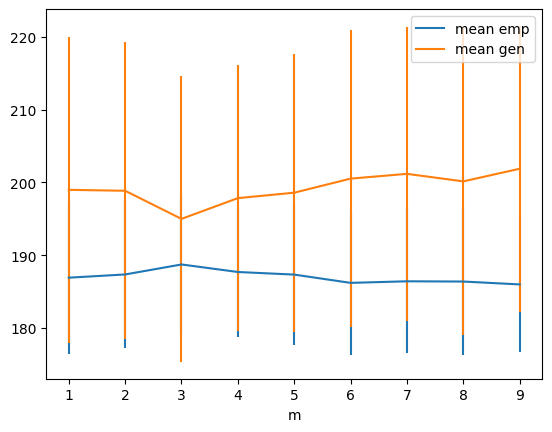

In [114]:
ax = taille_train_emp_errors.plot(kind="line",x="m",y="mean emp", yerr="std emp")
taille_train_gen_errors.plot(kind="line",x="m",y="mean gen", yerr="std gen",ax=ax)

### Exercice

Soit la base de données Boston contenant 13 attributs (criminalité, zonage, entreprises, fleuve Charles, concentration en oxydes d'azote, nombre de pièces, unités occupées par le propriétaire, distance moyenne vers les centres d'emploi, accessibilité aux autoroutes radiales, taux d'imposition, ratio élève/enseignant, pourcentage de statut inférieur, valeur médiane des résidences occupées par le propriétaire) et 506 entrées. Utiliser l'algorithme des  $𝑘$- plus-proches-voisins pour apprendre un modèle capable de prédire prédire le taux de criminalité en fonction des autres attributs (faites au préalable une analyse descriptive des attributs, une sélection des attributs pour un meilleur modèle). Utiliser la validation croisée pour sélection le nombre de voisins $k$.


In [115]:
boston = pd.read_csv("../data/Boston.csv", sep=",")
print( boston.columns )


Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'black', 'lstat', 'medv'],
      dtype='object')


In [120]:
from sklearn.neighbors import KNeighborsRegressor
boston_new = boston.drop(columns='chas', axis=1)
repeats = 200

best_k = []
m_gen_errors = []
m_emp_errors = []
for m in range(1, 21):
    gen_errors = [] # erreurs de generalisation
    emp_errors = [] # erreurs d'apprentissage
    for r in range(repeats):
        cv_boston = GridSearchCV(KNeighborsRegressor(),{"n_neighbors":[1,5,10,20,30]},cv=5,scoring="neg_mean_squared_error")
        y = boston_new['crim']
        x = boston_new.drop(columns = 'crim', axis=1)
        X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=1/3, random_state=r)
        cv_boston.fit(X_train,y_train)
        best_k.append(cv_boston.best_params_['n_neighbors'])
        gen_errors.append(mean_squared_error(y_test, cv_boston.predict(X_test)))
        emp_errors.append(mean_squared_error(y_train, cv_boston.predict(X_train)))
    m_gen_errors.append(np.mean(gen_errors))
    m_emp_errors.append(np.mean(emp_errors))
    
    
    

# best_k = best_k.sort()
# k_errors = pd.DataFrame({"k":best_k,"empirique":emp_errors,"généralisation":gen_errors})
# ax=k_errors.plot(kind="line",x="k",y="empirique")
# k_errors.plot(kind="line",x="k",y="généralisation", ax=ax)
# plt.title("Erreurs en fonction de k")
# plt.grid()
# plt.legend()



In [ ]:
from sklearn.cluster import AgglomerativeClustering


model = KNeighborsRegressor(**cv.best_params_)
model.fit(X_train,y_train)
Y_hat = model.predict(X_test)
mean_squared_error(y_test, Y_hat)

38.698842329445554